In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import json

from scipy.signal import butter, filtfilt, find_peaks


# ============================================================
# 0. 데이터 경로
# ============================================================

BASE_DIR = os.getcwd()

test1_list =[
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l01.csv"),
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r03.csv"),
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_l02.csv"),
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_r01.csv"),
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_l02.csv"),
    # os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_r04.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_l02.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "looking", "test_looking_3loop_r02.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_l02.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "swing", "test_swing_3loop_r02.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_l02.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data", "calling", "test_calling_3loop_r02.csv"),
]

test2_list =[
    os.path.join(BASE_DIR, "data", "tester1", "test_data3", "test3_looking_S22U.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data3", "test3_swing_S22U.csv"),
    os.path.join(BASE_DIR, "data", "tester1", "test_data3", "test3_calling_S22U.csv"),
]

FS = 50
DT = 0.02 
STEP_LENGTH = 0.7


In [2]:
def data_load(file_path, skiprows=50, skipfooter=50):
    df = pd.read_csv(file_path, skiprows=skiprows, skipfooter=skipfooter, engine="python")

    df.columns = [
        "Time",
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Magnetometer x",
        "Magnetometer y",
        "Magnetometer z",
        "Orientation x",
        "Orientation y",
        "Orientation z",
        "Pressure",
        "Latitude",
        "Longitude",
        "Altitude",
        "Speed_GPS",
    ]
    
    df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H:%M:%S.%f")
    start_dt = df["Time"].iloc[0]
    df["Elapsed Time"] = (df["Time"] - start_dt).dt.total_seconds()

    df["Acc_Norm"] = np.linalg.norm(
        df[["Accelerometer x", "Accelerometer y", "Accelerometer z"]].values, axis=1
    )
    
    return df

In [5]:
class PDR:
    """
    PDR (Pedestrian Dead Reckoning) class
    - input: df, step_length
    - output: x, y (predicted path)
    
    frequency: 50Hz
    dt: 0.02s 
    step_length: 0.7m (average step length)
    """
    
    def __init__(self, df, step_length=0.65):
        self.df = df 
        self.step_length = step_length
        self.frequency = 50
        self.dt = 0.02
        self.x = np.zeros(len(df))
        self.y = np.zeros(len(df))
        
        
    # def step_detection(self):
    #     # Step detection using accelerometer norm
    #     acc_norm = self.df["Acc_Norm"].values
        
    #     # butterworth low-pass filter to smooth the accelerometer norm signal
    #     nyquist = 0.5 * self.frequency
    #     normal_cutoff = 3.0 / nyquist
    #     b, a = butter(4, normal_cutoff, btype="low", analog=False)
    #     acc_norm_smoothed = filtfilt(b, a, acc_norm)
    #     peaks, _ = find_peaks(acc_norm_smoothed, height=11.5, distance=self.frequency*0.5)
    
    #     return peaks
    
    def step_detection(self):
        # Step detection using accelerometer norm
        acc_norm = self.df["Acc_Norm"].values
        
        # butterworth low-pass filter to smooth the accelerometer norm signal
        nyquist = 0.5 * self.frequency
        normal_cutoff = 3.0 / nyquist
        b, a = butter(4, normal_cutoff, btype="low", analog=False)
        acc_norm_smoothed = filtfilt(b, a, acc_norm)
        
        height = 11.5
        start_idx = 0
        end_idx = 1000
        
        peaks, properties = find_peaks(
            acc_norm_smoothed,
            height=height,
            distance=int(self.frequency * 0.1)
        )
        
        # 1000~3000 구간에 있는 peak만 선택
        plot_peaks = peaks[(peaks >= start_idx) & (peaks < end_idx)]
        
        plt.figure(figsize=(14, 5))
        
        plt.plot(
            self.df["Elapsed Time"].iloc[start_idx:end_idx],
            acc_norm[start_idx:end_idx],
            label="Acc Norm",
            alpha=0.4
        )
        
        plt.plot(
            self.df["Elapsed Time"].iloc[start_idx:end_idx],
            acc_norm_smoothed[start_idx:end_idx],
            label="Smoothed Acc Norm",
            linewidth=2
        )
        
        # 임계치 선
        plt.axhline(
            y=height,
            linestyle="--",
            label=f"Threshold = {height}"
        )
        
        # 검출된 peak 표시
        plt.scatter(
            self.df["Elapsed Time"].iloc[plot_peaks],
            acc_norm_smoothed[plot_peaks],
            marker="x",
            s=80,
            label=f"Detected Peaks = {len(plot_peaks)}"
        )
        
        plt.legend()
        plt.xlabel("Time (s)")
        plt.ylabel("Acceleration (m/s^2)")
        plt.title("Accelerometer Norm, Smoothed Signal, and Detected Peaks")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        print(f"전체 검출 걸음 수: {len(peaks)}")
        print(f"{start_idx}~{end_idx} 구간 검출 걸음 수: {len(plot_peaks)}")
        print("구간 내 peak index:", plot_peaks)
        
        return peaks
    
    
    
    def heading_estimation(self):
        # 스마트폰 API, Game Rotation Vector에서 제공하는 쿼터니언
        qx = self.df["Orientation x"].values
        qy = self.df["Orientation y"].values
        qz = self.df["Orientation z"].values
        
        # qw 복원
        qw_sq = 1.0 - (qx**2 + qy**2 + qz**2)
        qw_sq = np.clip(qw_sq, 0.0, None)
        qw = np.sqrt(qw_sq)
        
        # =========================
        # 4. 쿼터니언 부호 연속성 보정
        # =========================
        for i in range(1, len(qw)):
            dot = (
                qw[i-1] * qw[i]
                + qx[i-1] * qx[i]
                + qy[i-1] * qy[i]
                + qz[i-1] * qz[i]
            )
            if dot < 0:
                qw[i] = -qw[i]
                qx[i] = -qx[i]
                qy[i] = -qy[i]
                qz[i] = -qz[i]
                
        pitch = np.arctan2(
            2.0 * (qw * qx + qy * qz),
            1.0 - 2.0 * (qx * qx + qy * qy)
        )
        
        roll = 2.0 * (qw * qy - qz * qx)
        roll = np.clip(roll, -1.0, 1.0)
        roll = np.arcsin(roll)
        
        print("pitch:", np.degrees(pitch))
        print("roll:",np.degrees(roll))
        
        gx = self.df["Gyroscope x"].values
        gy = self.df["Gyroscope y"].values
        gz = self.df["Gyroscope z"].values
        
        gyro_corr = np.zeros((len(self.df), 3))
        
        for i in range(len(gx)):
            cos_p = np.cos(pitch[i])
            sin_p = np.sin(pitch[i])
            
            cos_r = np.cos(roll[i])
            sin_r = np.sin(roll[i])
            
            R_inv_roll = np.array([
                [cos_r, 0, sin_r],
                [0, 1, 0],
                [-sin_r, 0, cos_r]
            ])
            
            R_inv_pitch = np.array([
                [1, 0, 0],
                [0, cos_p, -sin_p],
                [0, sin_p, cos_p]
            ])
            
            R_tilt = R_inv_roll @ R_inv_pitch 
            
            gyro_vetor = np.array([gx[i], gy[i], gz[i]])
            gyro_corr[i] = R_tilt @ gyro_vetor
            
            gx_corr = gyro_corr[:, 0]
            gy_corr = gyro_corr[:, 1]
            gz_corr = gyro_corr[:, 2]
            
            
        heading = np.cumsum(gz_corr) * self.dt # gyro angular velocity * dt(0.02s)
        
        return heading
    
    def predict_path(self, target_heading=None):
        step_indices = self.step_detection()
        heading = self.heading_estimation()

        init_x, init_y = 0.0, 0.0
        x_list, y_list = [init_x], [init_y]
        
        psi_list = [0.0]
       
        for step_idx in step_indices:
            psi = heading[step_idx]
            cur_x, cur_y = x_list[-1], y_list[-1]
            new_x = cur_x + self.step_length * np.cos(psi)
            new_y = cur_y + self.step_length * np.sin(psi)
            x_list.append(new_x)
            y_list.append(new_y)
            psi_list.append(psi)
        
        self.x = np.array(x_list)
        self.y = np.array(y_list)
        heading_list = np.array(psi_list)
        
        final_x = self.x[-1]
        final_y = self.y[-1]
        
        print("========== PDR Evaluation ==========")
        print(f"Final Position: ({final_x:.3f}, {final_y:.3f}) m")


        target_x, target_y = 0, 0

        final_pos_error = np.sqrt(
            (final_x - target_x) ** 2 +
            (final_y - target_y) ** 2
        )

        print(f"Target Position: ({target_x:.3f}, {target_y:.3f}) m")
        print(f"Final Position Error: {final_pos_error:.3f} m")
        
        final_heading = heading[-1]
        final_heading_deg = np.degrees(final_heading)
        
        print(f"Final Heading: {final_heading_deg:.3f} deg")

        if target_heading is not None:
            heading_error_deg = abs(final_heading_deg) - abs(target_heading)
            heading_abs_error_deg = abs(heading_error_deg)

            #print(f"Target Heading: {target_heading:.3f} deg")
            print(f"Heading Error: {heading_error_deg:.3f} deg")
            print(f"Absolute Heading Error: {heading_abs_error_deg:.3f} deg")

        print("====================================")
        return self.x, self.y, heading_list
        

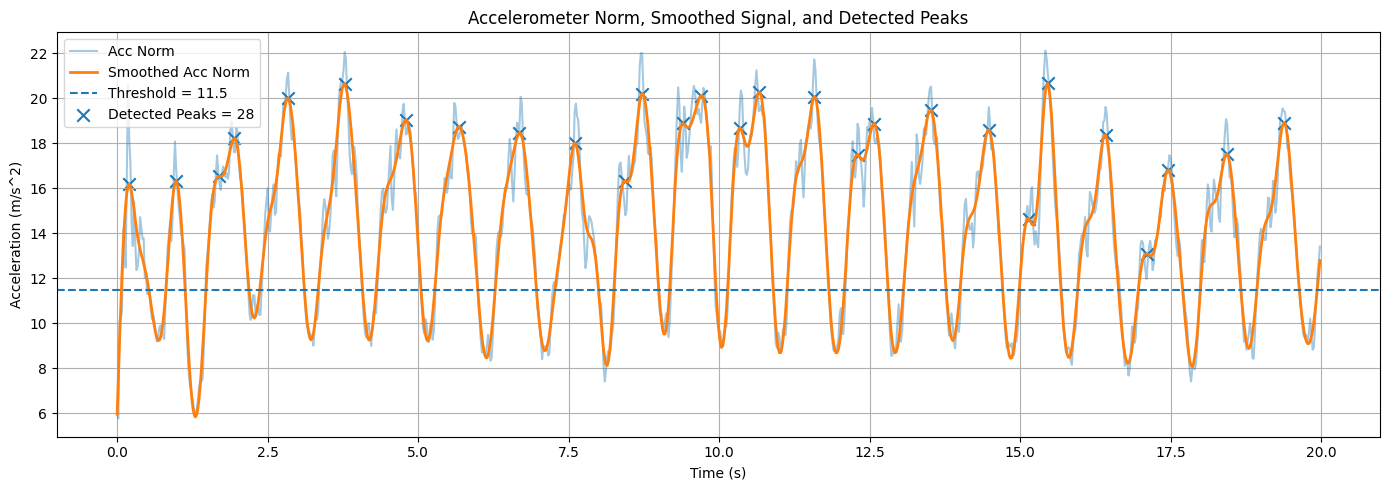

전체 검출 걸음 수: 195
0~1000 구간 검출 걸음 수: 28
구간 내 peak index: [ 10  49  85  97 142 189 240 284 334 380 422 436 470 485 517 533 579 615
 629 676 724 757 773 821 855 873 922 969]
pitch: [ 27.23225653  25.62081239  22.52159686 ... -94.69000402 -94.17701751
 -93.86158906]
roll: [-37.41441703 -43.33147498 -49.16478632 ...  -7.36044112  -7.07930852
  -6.98417186]
========== PDR Evaluation ==========
Final Position: (0.289, -7.365) m
Target Position: (0.000, 0.000) m
Final Position Error: 7.370 m
Final Heading: 639.725 deg
Heading Error: -440.275 deg
Absolute Heading Error: 440.275 deg


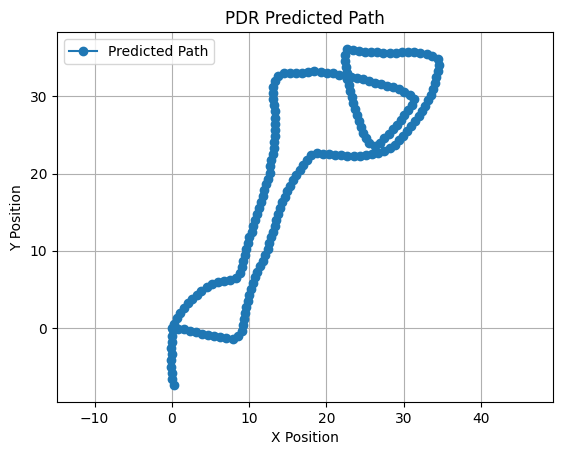

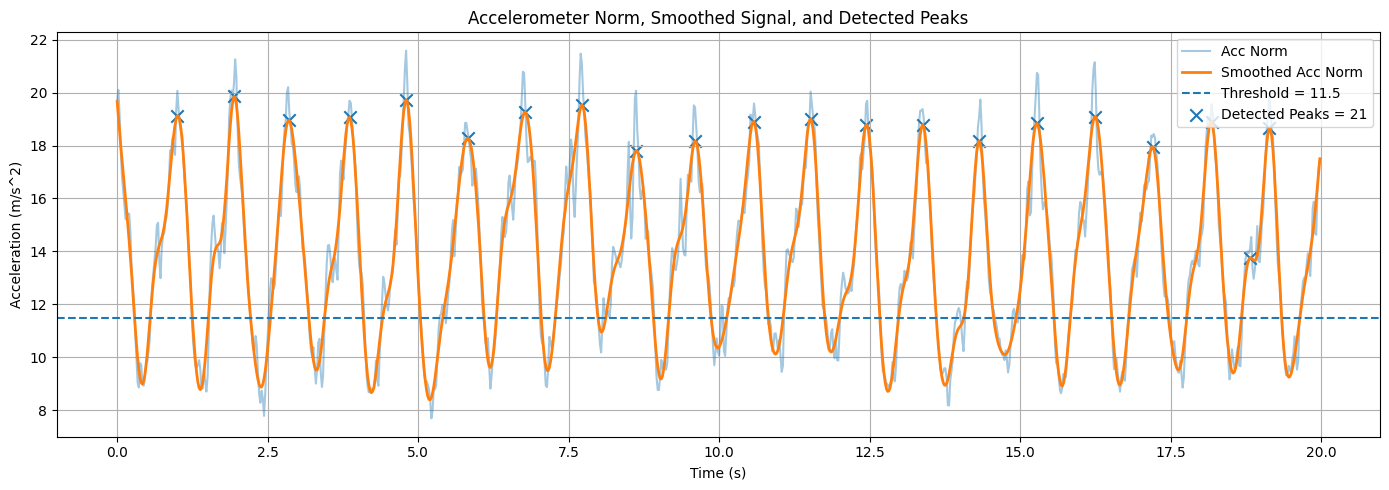

전체 검출 걸음 수: 168
0~1000 구간 검출 걸음 수: 21
구간 내 peak index: [ 50  97 143 193 240 291 339 386 431 480 529 576 622 669 716 764 812 860
 909 941 957]
pitch: [-97.32699262 -97.16213442 -96.85839429 ... -94.61092463 -94.4340691
 -93.93349904]
roll: [-22.86453163 -24.09384103 -26.93167799 ... -36.82446734 -36.82098346
 -37.35503953]
========== PDR Evaluation ==========
Final Position: (13.843, 54.508) m
Target Position: (0.000, 0.000) m
Final Position Error: 56.239 m
Final Heading: -267.186 deg
Heading Error: -812.814 deg
Absolute Heading Error: 812.814 deg


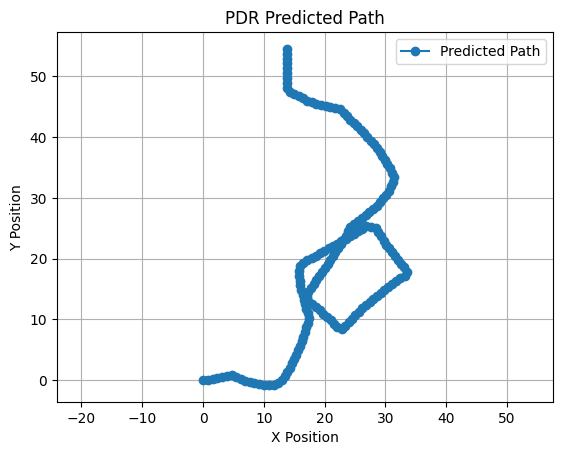

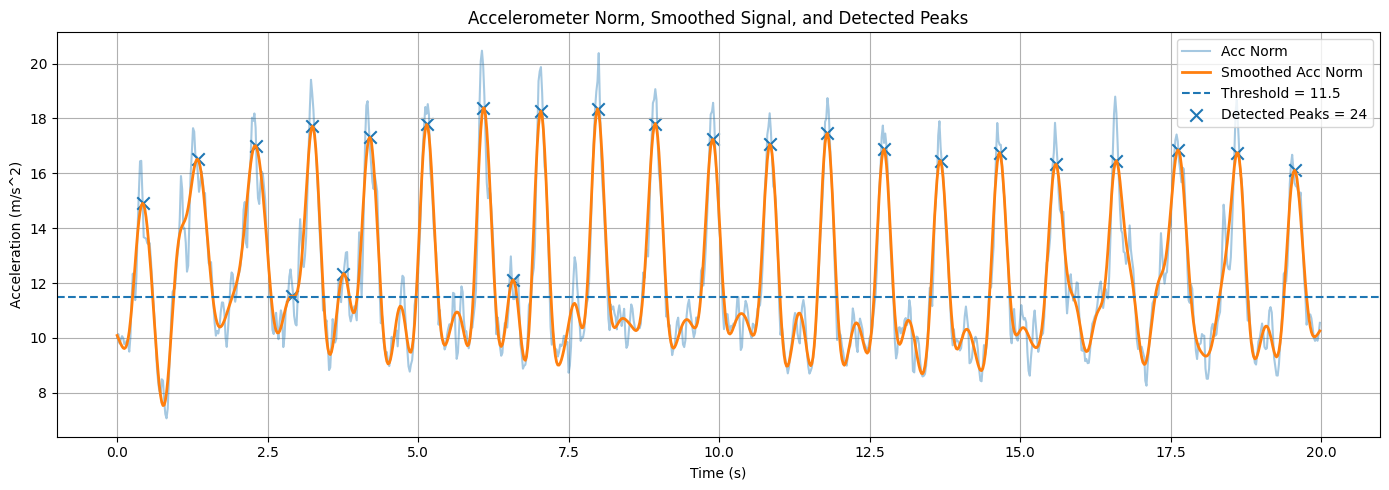

전체 검출 걸음 수: 97
0~1000 구간 검출 걸음 수: 24
구간 내 peak index: [ 21  67 115 145 162 188 210 257 304 329 352 399 447 495 542 590 637 684
 733 780 830 881 930 978]
pitch: [-92.69546253 -92.50835555 -92.34918876 ... -88.0740353  -87.90499455
 -86.92938773]
roll: [-30.89543506 -30.82476408 -30.80330729 ... -39.90856117 -39.63944215
 -39.31321946]
========== PDR Evaluation ==========
Final Position: (7.130, -0.701) m
Target Position: (0.000, 0.000) m
Final Position Error: 7.165 m
Final Heading: 0.034 deg
Heading Error: 0.034 deg
Absolute Heading Error: 0.034 deg


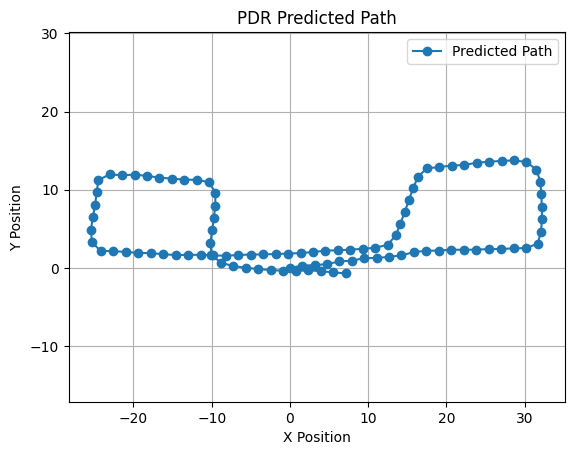

In [ ]:
test1_left_target_heading = 1080.0
test1_right_target_heading = -1080.0
test2_target_heading = 0.0

test1_looking_left_df = data_load(test1_list[0])
test1_looking_right_df = data_load(test1_list[1])

# test1_swing_left_df = data_load(test1_list[2], skiprows=150)
# test1_swing_right_df = data_load(test1_list[3], skiprows=150)

# test1_calling_left_df = data_load(test1_list[4], skiprows=150)
# test1_calling_right_df = data_load(test1_list[5], skiprows=150)

# test2_looking_df = data_load(test2_list[0])
# test2_swing_df = data_load(test2_list[1], skiprows=150)
# test2_calling_df = data_load(test2_list[2], skiprows=150)


# pdr = PDR(test1_looking_left_df, step_length=0.8)
# path = pdr.predict_path(test1_left_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()



# pdr = PDR(test1_looking_right_df, step_length=0.8)
# path = pdr.predict_path(test1_right_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

# pdr = PDR(test1_swing_left_df, step_length=0.8)
# path = pdr.predict_path(test1_left_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

# pdr = PDR(test1_swing_right_df, step_length=0.8)
# path = pdr.predict_path(test1_right_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

# pdr = PDR(test1_calling_left_df, step_length=0.8)
# path = pdr.predict_path(test1_left_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

# pdr = PDR(test1_calling_right_df, step_length=0.8)
# path = pdr.predict_path(test1_right_target_heading)

# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

# pdr = PDR(test2_looking_df, step_length=0.8)
# path = pdr.predict_path(test2_target_heading)
# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

pdr = PDR(test2_swing_df, step_length=1.6)
path = pdr.predict_path(test2_target_heading)
plt.plot(path[0], path[1], marker="o", label="Predicted Path")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("PDR Predicted Path")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

# pdr = PDR(test2_calling_df, step_length=0.8)
# path = pdr.predict_path(test2_target_heading)
# plt.plot(path[0], path[1], marker="o", label="Predicted Path")
# plt.xlabel("X Position")
# plt.ylabel("Y Position")
# plt.title("PDR Predicted Path")
# plt.axis("equal")
# plt.grid()
# plt.legend()
# plt.show()

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Target Heading 설정
# ============================================================
test1_left_target_heading = 1080.0
test1_right_target_heading = -1080.0
test2_target_heading = 0.0


# ============================================================
# 2. 데이터 로드
# ============================================================
test1_looking_left_df = data_load(test1_list[0])
test1_looking_right_df = data_load(test1_list[1])

test1_swing_left_df = data_load(test1_list[2], skiprows=150)
test1_swing_right_df = data_load(test1_list[3], skiprows=150)

test1_calling_left_df = data_load(test1_list[4], skiprows=150)
test1_calling_right_df = data_load(test1_list[5], skiprows=150)

test2_looking_df = data_load(test2_list[0])
test2_swing_df = data_load(test2_list[1], skiprows=150)
test2_calling_df = data_load(test2_list[2], skiprows=150)


# ============================================================
# 3. 저장 경로 설정
# ============================================================
BASE_DIR = os.getcwd()

SAVE_DIR = os.path.join(
    BASE_DIR,
    "results",
    "conv"
)

os.makedirs(SAVE_DIR, exist_ok=True)


# ============================================================
# 4. PDR 실행 + CSV 저장 + Plot 함수
# ============================================================
def run_pdr_and_save(
    df,
    save_name,
    target_heading,
    step_length=1.6,
    plot=True,
    flag=False
):
    """
    df             : PDR 입력 데이터프레임
    save_name      : 저장할 csv 파일 이름. 확장자 제외
    target_heading : 목표 heading 변화량, degree
    step_length    : 보폭
    plot           : 경로 plot 여부
    flag           : left 회전 보정 적용 여부
    """

    pdr = PDR(df, step_length=step_length)

    # flag를 PDR 내부 predict_path로 전달
    x_, y_, heading = pdr.predict_path(
        target_heading=target_heading,
    )

    x = x_
    y = y_
    
    if flag:
        x = -x
        y = -y

    path_df = pd.DataFrame({
        "step_index": np.arange(len(x)),
        "x": x,
        "y": y,
        "heading": heading
    })

    save_path = os.path.join(SAVE_DIR, f"{save_name}.csv")
    path_df.to_csv(save_path, index=False, encoding="utf-8-sig")

    print(f"[Saved] {save_path}")
    print(f"flag = {flag}")

    if plot:
        plt.figure(figsize=(7, 5))
        plt.plot(x, y, marker="o", label="Predicted Path")
        plt.scatter(x[0], y[0], s=120, marker="s", label="Start")
        plt.scatter(x[-1], y[-1], s=160, marker="*", label="End")
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.title(f"PDR Predicted Path - {save_name}")
        plt.axis("equal")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return path_df


# ============================================================
# 5. 실행 목록 정의
# ============================================================
pdr_cases = [

    # {
    #     "name": "test1_swing_left",
    #     "df": test1_swing_left_df,
    #     "target_heading": test1_left_target_heading,
    #     "flag": True,
    # },
    # {
    #     "name": "test1_swing_right",
    #     "df": test1_swing_right_df,
    #     "target_heading": test1_right_target_heading,
    #     "flag": False,
    # },
    # {
    #     "name": "test2_swing",
    #     "df": test2_swing_df,
    #     "target_heading": test2_target_heading,
    #     "flag": False,
    # },
    

    {
        "name": "test1_looking_left",
        "df": test1_looking_left_df,
        "target_heading": test1_left_target_heading,
        "flag": True,
    },
    {
        "name": "test1_looking_right",
        "df": test1_looking_right_df,
        "target_heading": test1_right_target_heading,
        "flag": False,
    },

    {
        "name": "test1_calling_left",
        "df": test1_calling_left_df,
        "target_heading": test1_left_target_heading,
        "flag": True,
    },
    {
        "name": "test1_calling_right",
        "df": test1_calling_right_df,
        "target_heading": test1_right_target_heading,
        "flag": False,
    },
    {
        "name": "test2_looking",
        "df": test2_looking_df,
        "target_heading": test2_target_heading,
        "flag": False,
    },
    {
        "name": "test2_calling",
        "df": test2_calling_df,
        "target_heading": test2_target_heading,
        "flag": False,
    },
]


# ============================================================
# 6. 전체 실행
# ============================================================
saved_paths = {}

for case in pdr_cases:
    path_df = run_pdr_and_save(
        df=case["df"],
        save_name=case["name"],
        target_heading=case["target_heading"],
        step_length=0.8,
        plot=True,
        flag=case.get("flag", False)
    )

    saved_paths[case["name"]] = path_df